In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

# Cấu hình đồ họa
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Xác định đường dẫn file dữ liệu dựa trên cấu trúc thư mục
DATA_PATH = os.path.join("..", "dataset","raw", "New_Attack_Dataset.csv")
print(f"Đường dẫn file dữ liệu: {DATA_PATH}")

Đường dẫn file dữ liệu: ..\dataset\raw\New_Attack_Dataset.csv


In [2]:
# 1. Đọc file CSV
df = pd.read_csv(DATA_PATH)

# 2. Kiểm tra thông tin cơ bản
print("--- TỔNG QUAN TẬP DỮ LIỆU ---")
print(f"Tổng số dòng (mẫu văn bản): {df.shape[0]}")
print(f"Số lượng cột: {df.shape[1]} ({', '.join(df.columns)})")
print("\n--- KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (NULL) ---")
print(df.isnull().sum())

# 3. Hiển thị 5 dòng đầu tiên để kiểm tra cấu trúc
df.head()

--- TỔNG QUAN TẬP DỮ LIỆU ---
Tổng số dòng (mẫu văn bản): 22399
Số lượng cột: 2 (Cleaned_Text, Labels)

--- KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (NULL) ---
Cleaned_Text    0
Labels          0
dtype: int64


,Cleaned_Text,Labels
0,Authentication Bypass via SQL Injection Mobile...,"T1078,T1190"
1,Union-Based SQL Injection AI Agents & LLM Expl...,T1190
2,Error-Based SQL Injection AI Agents & LLM Expl...,T1190
3,Blind SQL Injection AI Agents & LLM Exploits S...,T1190
4,Second-Order SQL Injection AI Agents & LLM Exp...,T1505


--- THỐNG KÊ SỐ LƯỢNG NHÃN TRÊN MỖI CÂU ---
count    22399.000000
mean         1.101478
std          0.345156
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: Label_Count, dtype: float64


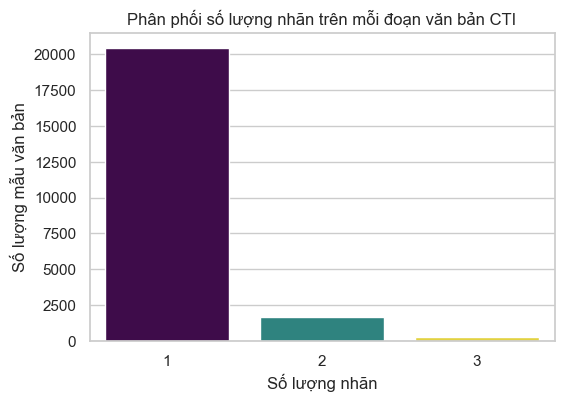

In [3]:
# Chuyển đổi chuỗi nhãn phân tách bằng dấu phẩy thành danh sách (List)
# Ví dụ: "T1059,T1557" -> ['T1059', 'T1557']
df['Label_List'] = df['Labels'].apply(lambda x: [lbl.strip() for lbl in str(x).split(',')] if pd.notnull(x) else [])

# Tính toán số lượng nhãn trên mỗi câu
df['Label_Count'] = df['Label_List'].apply(len)

print("--- THỐNG KÊ SỐ LƯỢNG NHÃN TRÊN MỖI CÂU ---")
print(df['Label_Count'].describe())

# Trực quan hóa số lượng nhãn trên từng câu
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label_Count', hue='Label_Count', palette="viridis", legend=False)
plt.title("Phân phối số lượng nhãn trên mỗi đoạn văn bản CTI")
plt.xlabel("Số lượng nhãn")
plt.ylabel("Số lượng mẫu văn bản")
plt.show()

Tổng số nhãn độc nhất xuất hiện thực tế: 378

--- PHÂN TÁCH CHO KIẾN TRÚC TWO-STAGE ---
Mức ngưỡng phân tách được chọn: >= 30 mẫu
Stage 1 - Lõi Phân Loại Chính: 108 nhãn (Phổ biến)
Stage 2 - Bộ Lọc Ngoại Lai (Vector DB): 270 nhãn (Thiểu số/Hiếm)
Tỷ lệ bao phủ của Stage 1 trên tổng lượt xuất hiện nhãn: 93.05%


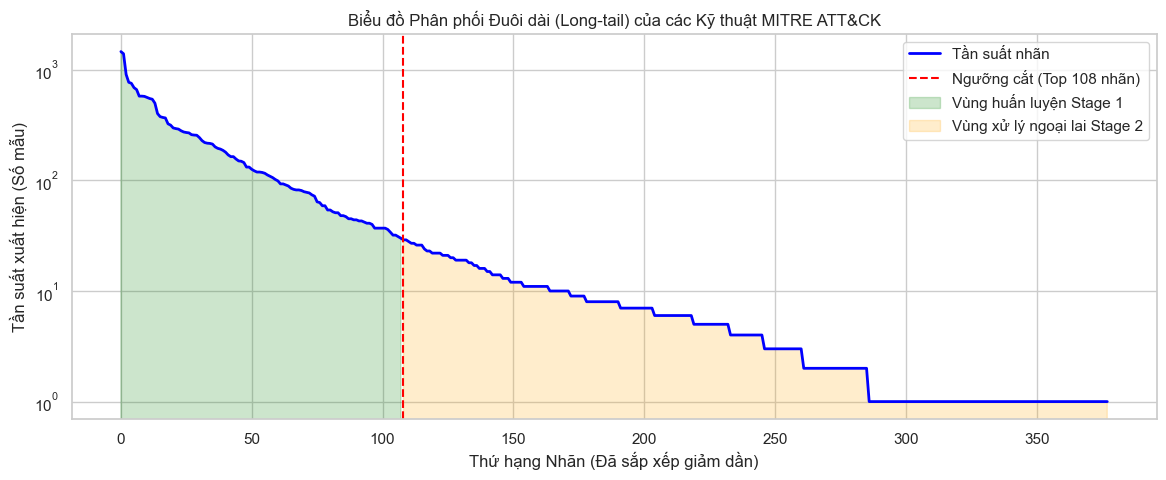

In [5]:
# Giải phẳng danh sách nhãn để đếm tổng tần suất
all_labels = [label for sublist in df['Label_List'] for label in sublist]
label_counts = Counter(all_labels)

print(f"Tổng số nhãn độc nhất xuất hiện thực tế: {len(label_counts)}")

# Chuyển thành DataFrame để dễ xử lý và vẽ đồ thị
df_label_freq = pd.DataFrame(label_counts.items(), columns=['MITRE_Technique', 'Frequency']).sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# Khảo sát ngưỡng cắt cho Kiến trúc Mô hình kép 
THRESHOLD = 30
stage_1_labels = df_label_freq[df_label_freq['Frequency'] >= THRESHOLD]
stage_2_labels = df_label_freq[df_label_freq['Frequency'] < THRESHOLD]

print("\n--- PHÂN TÁCH CHO KIẾN TRÚC TWO-STAGE ---")
print(f"Mức ngưỡng phân tách được chọn: >= {THRESHOLD} mẫu")
print(f"Stage 1 - Lõi Phân Loại Chính: {len(stage_1_labels)} nhãn (Phổ biến)")
print(f"Stage 2 - Bộ Lọc Ngoại Lai (Vector DB): {len(stage_2_labels)} nhãn (Thiểu số/Hiếm)")

# Tính toán tỷ lệ bao phủ dữ liệu của Stage 1
total_label_occurrences = df_label_freq['Frequency'].sum()
stage_1_coverage = (stage_1_labels['Frequency'].sum() / total_label_occurrences) * 100
print(f"Tỷ lệ bao phủ của Stage 1 trên tổng lượt xuất hiện nhãn: {stage_1_coverage:.2f}%")

# Vẽ biểu đồ phân phối đuôi dài cực đoan
plt.figure(figsize=(14, 5))
plt.plot(df_label_freq.index, df_label_freq['Frequency'], label='Tần suất nhãn', color='blue', linewidth=2)
plt.axvline(x=len(stage_1_labels), color='red', linestyle='--', label=f'Ngưỡng cắt (Top {len(stage_1_labels)} nhãn)')
plt.fill_between(df_label_freq.index, df_label_freq['Frequency'], where=(df_label_freq.index < len(stage_1_labels)), alpha=0.2, color='green', label='Vùng huấn luyện Stage 1')
plt.fill_between(df_label_freq.index, df_label_freq['Frequency'], where=(df_label_freq.index >= len(stage_1_labels)), alpha=0.2, color='orange', label='Vùng xử lý ngoại lai Stage 2')

plt.title("Biểu đồ Phân phối Đuôi dài (Long-tail) của các Kỹ thuật MITRE ATT&CK")
plt.xlabel("Thứ hạng Nhãn (Đã sắp xếp giảm dần)")
plt.ylabel("Tần suất xuất hiện (Số mẫu)")
plt.legend()
plt.yscale('log') # Dùng log scale vì phân phối chênh lệch cực đoan
plt.show()

--- THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ) ---
count    22399.000000
mean       118.288361
std        111.300211
min          1.000000
25%         17.000000
50%        111.000000
75%        165.000000
90%        257.000000
95%        311.000000
99%        513.000000
max       1072.000000
Name: Word_Count, dtype: float64


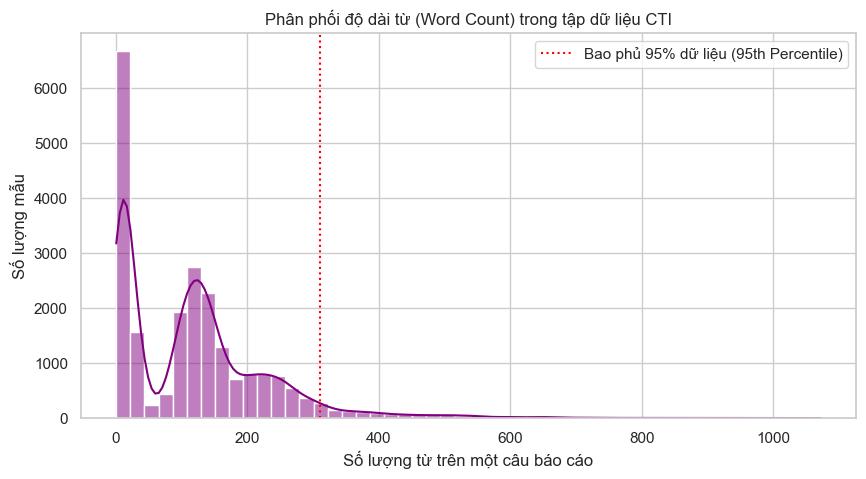

In [6]:
# Tính số lượng từ (Word Count) và số lượng ký tự (Character Count) của văn bản đã làm sạch
df['Word_Count'] = df['Cleaned_Text'].apply(lambda x: len(str(x).split()))
df['Char_Count'] = df['Cleaned_Text'].apply(lambda x: len(str(x)))

print("--- THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ) ---")
print(df['Word_Count'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

# Trực quan hóa phân phối độ dài câu để chọn tham số cấu hình cho Mô hình học sâu
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Word_Count', bins=50, kde=True, color='purple')
plt.axvline(x=df['Word_Count'].quantile(0.95), color='red', linestyle=':', label='Bao phủ 95% dữ liệu (95th Percentile)')
plt.title("Phân phối độ dài từ (Word Count) trong tập dữ liệu CTI")
plt.xlabel("Số lượng từ trên một câu báo cáo")
plt.ylabel("Số lượng mẫu")
plt.legend()
plt.show()

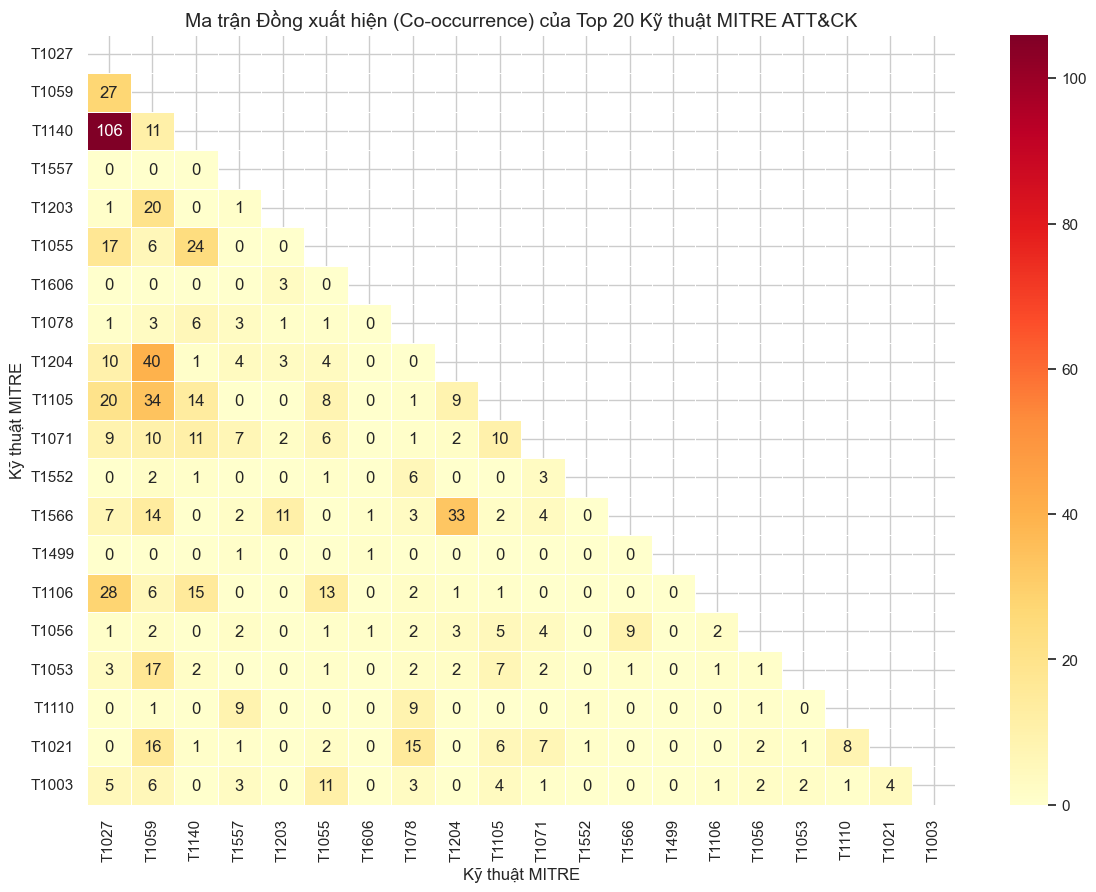

In [7]:
import numpy as np

# Lấy ra Top 20 nhãn phổ biến nhất để dễ trực quan hóa
top_20_labels = df_label_freq['MITRE_Technique'].head(20).tolist()

# Khởi tạo ma trận vuông 20x20 với các giá trị 0
co_occurrence_matrix = pd.DataFrame(np.zeros((20, 20)), index=top_20_labels, columns=top_20_labels)

# Tính toán số lần đồng xuất hiện
for labels in df['Label_List']:
    # Chỉ xét các nhãn nằm trong top 20
    relevant_labels = [lbl for lbl in labels if lbl in top_20_labels]
    # Tăng giá trị cho các cặp nhãn
    for i in range(len(relevant_labels)):
        for j in range(i + 1, len(relevant_labels)):
            co_occurrence_matrix.loc[relevant_labels[i], relevant_labels[j]] += 1
            co_occurrence_matrix.loc[relevant_labels[j], relevant_labels[i]] += 1 # Ma trận đối xứng

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(14, 10))
# Mask nửa trên của ma trận vì nó đối xứng, giúp biểu đồ thoáng hơn
mask = np.triu(np.ones_like(co_occurrence_matrix, dtype=bool))
sns.heatmap(co_occurrence_matrix, mask=mask, annot=True, fmt="g", cmap="YlOrRd", linewidths=.5)
plt.title("Ma trận Đồng xuất hiện (Co-occurrence) của Top 20 Kỹ thuật MITRE ATT&CK", fontsize=14)
plt.xlabel("Kỹ thuật MITRE")
plt.ylabel("Kỹ thuật MITRE")
plt.show()

--- ĐANG TRÍCH XUẤT ĐẶC TRƯNG TỪ VỰNG... ---


C:\Users\84354\AppData\Local\Temp\ipykernel_11296\2160929697.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=df_ngram, palette='mako')


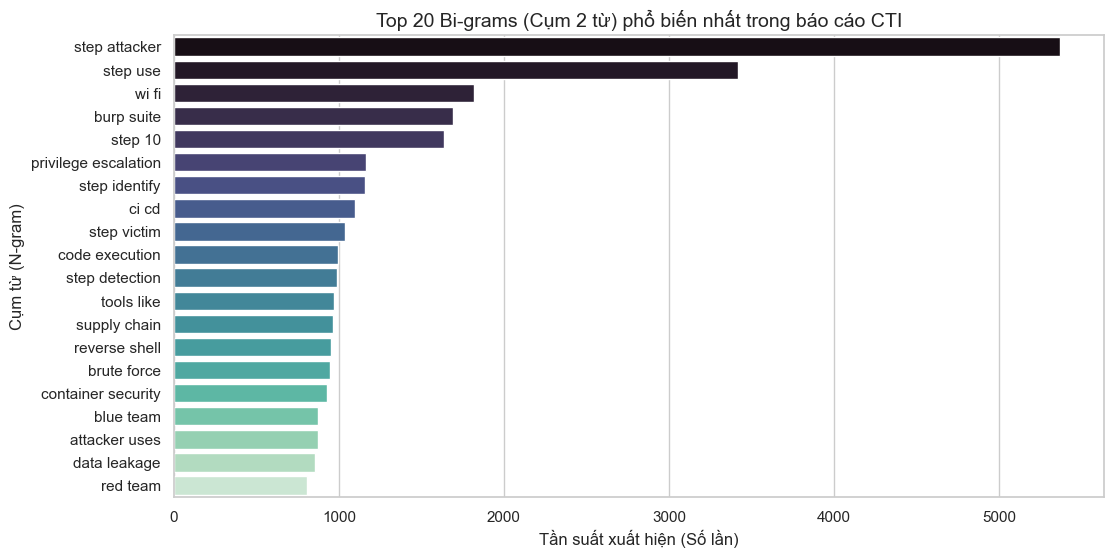

C:\Users\84354\AppData\Local\Temp\ipykernel_11296\2160929697.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=df_ngram, palette='mako')


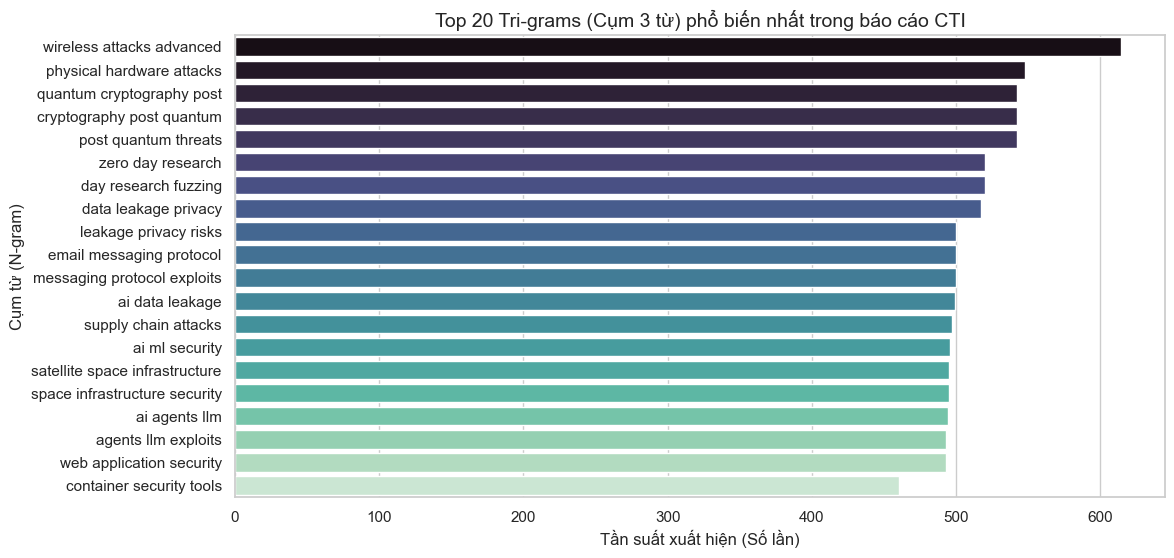

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, ngram_range=(2, 2), top_n=20, title=""):
    """Hàm hỗ trợ trích xuất và vẽ đồ thị các cụm từ phổ biến"""
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]
    
    df_ngram = pd.DataFrame(words_freq, columns=['N-gram', 'Frequency'])
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Frequency', y='N-gram', data=df_ngram, palette='mako')
    plt.title(title, fontsize=14)
    plt.xlabel("Tần suất xuất hiện (Số lần)")
    plt.ylabel("Cụm từ (N-gram)")
    plt.show()

print("--- ĐANG TRÍCH XUẤT ĐẶC TRƯNG TỪ VỰNG... ---")
# Vẽ Top 20 Bi-grams (Cụm 2 từ)
plot_top_ngrams(df['Cleaned_Text'].dropna(), ngram_range=(2, 2), top_n=20, title="Top 20 Bi-grams (Cụm 2 từ) phổ biến nhất trong báo cáo CTI")

# Vẽ Top 20 Tri-grams (Cụm 3 từ)
plot_top_ngrams(df['Cleaned_Text'].dropna(), ngram_range=(3, 3), top_n=20, title="Top 20 Tri-grams (Cụm 3 từ) phổ biến nhất trong báo cáo CTI")

In [9]:
# 1. Kiểm tra dòng trùng lặp (dựa trên nội dung văn bản)
duplicate_count = df.duplicated(subset=['Cleaned_Text']).sum()
print(f"--- KIỂM TRA TRÙNG LẶP ---")
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

if duplicate_count > 0:
    # Hiển thị vài ví dụ trùng lặp để xem xét
    print("Mẫu các dòng bị trùng:")
    print(df[df.duplicated(subset=['Cleaned_Text'], keep=False)].head(5))
    
    # Bạn có thể quyết định xóa hoặc giữ
    # df = df.drop_duplicates(subset=['Cleaned_Text'])
    # print("Đã xóa các dòng trùng lặp.")

# 2. Kiểm tra các dòng không có nhãn
# Dựa trên file gốc, cột Labels có thể là NaN hoặc chuỗi rỗng
missing_labels = df[df['Labels'].isnull() | (df['Labels'].str.strip() == '')]
print(f"\n--- KIỂM TRA NHÃN THIẾU ---")
print(f"Số lượng dòng không có nhãn: {len(missing_labels)}")

if len(missing_labels) > 0:
    print("Mẫu các dòng thiếu nhãn:")
    print(missing_labels.head(5))
    
    # Loại bỏ các dòng không có nhãn vì không dùng được cho Supervised Learning
    df = df.dropna(subset=['Labels'])
    df = df[df['Labels'].str.strip() != '']
    print(f"\nĐã loại bỏ các dòng thiếu nhãn. Số dòng còn lại: {len(df)}")

--- KIỂM TRA TRÙNG LẶP ---
Số lượng dòng trùng lặp: 0

--- KIỂM TRA NHÃN THIẾU ---
Số lượng dòng không có nhãn: 0


In [10]:
# Tính toán số lượng mẫu cho mỗi mức số lượng nhãn
label_distribution = df.groupby('Label_Count').size().reset_index(name='Sample_Count')

# Tính tỷ lệ phần trăm
label_distribution['Percentage'] = (label_distribution['Sample_Count'] / len(df) * 100).round(2)

# In kết quả ra terminal
print(f"{'Label Count':<15} | {'Sample Count':<15} | {'Percentage (%)':<15}")
print("-" * 50)
for _, row in label_distribution.iterrows():
    print(f"{int(row['Label_Count']):<15} | {int(row['Sample_Count']):<15} | {row['Percentage']:<15}")

Label Count     | Sample Count    | Percentage (%) 
--------------------------------------------------
1               | 20439           | 91.25          
2               | 1647            | 7.35           
3               | 313             | 1.4            


In [11]:
# Lọc các dòng có Label_Count nằm trong danh sách [4, 5, 6, 8, 15]
rare_samples_df = df[df['Label_Count'].isin([4, 5, 6, 8, 15])].copy()

# Chọn ra 2 cột cần thiết để xem xét: nội dung và nhãn hiện tại
rare_samples_to_review = rare_samples_df[['Cleaned_Text', 'Labels']]

# Lưu ra file CSV để bạn có thể mở bằng Excel/Notepad và gửi cho tôi
rare_samples_to_review.to_csv("rare_samples_to_review.csv", index=False)

print(f"Đã trích xuất {len(rare_samples_to_review)} dòng dữ liệu cần chỉnh sửa nhãn.")
print("File 'rare_samples_to_review.csv' đã được tạo. Bạn hãy tải file này xuống và gửi nội dung cho tôi nhé.")

Đã trích xuất 0 dòng dữ liệu cần chỉnh sửa nhãn.
File 'rare_samples_to_review.csv' đã được tạo. Bạn hãy tải file này xuống và gửi nội dung cho tôi nhé.


In [12]:
# Cấu hình ánh xạ các bộ nhãn cũ sang bộ nhãn mới
# Key: Chuỗi nhãn cũ (cần khớp chính xác với cột 'Labels' trong dataset)
# Value: Chuỗi nhãn mới đã được tinh giản
label_mapping = {
    "T1021,T1046,T1078,T1210": "T1021,T1046,T1078",
    "T1021,T1040,T1210,T1563": "T1021,T1040,T1563",
    "T1043,T1059,T1071,T1571": "T1059,T1071,T1571",
    "T1048,T1059,T1071,T1090": "T1059,T1071,T1090",
    "T1020,T1048,T1095,T1572": "T1048,T1095,T1572",
    "T1053,T1055,T1547,T1564": "T1053,T1547,T1564",
    "T1021,T1053,T1059,T1105": "T1021,T1059,T1105",
    "T1021,T1059,T1075,T1105": "T1021,T1059,T1105",
    "T1018,T1033,T1057,T1082,T1087": "T1018,T1082,T1087",
    "T1037,T1053,T1204,T1546": "T1037,T1053,T1546",
    "T1202,T1218,T1546,T1556": "T1202,T1546,T1556",
    "T1056,T1071,T1219,T1546": "T1056,T1071,T1219",
    "T1056,T1204,T1546,T1556": "T1056,T1546,T1556",
    "T1078,T1086,T1552,T1557": "T1078,T1086,T1552",
    "T1021,T1071,T1552,T1566": "T1021,T1071,T1552",
    "T1059,T1190,T1203,T1552": "T1059,T1190,T1552",
    "T1078,T1210,T1486,T1530": "T1078,T1486,T1530",
    "T1033,T1041,T1053,T1082": "T1033,T1041,T1082",
    "T1016,T1078,T1210,T1570": "T1078,T1210,T1570",
    "T1059,T1218,T1543,T1569,T1570": "T1543,T1569,T1570",
    "T1041,T1056,T1105,T1113": "T1041,T1056,T1113",
    "T1056,T1078,T1082,T1566": "T1056,T1078,T1082",
    "T1027,T1059,T1078,T1106,T1140,T1548": "T1078,T1140,T1548",
    "T1005,T1057,T1083,T1518": "T1057,T1083,T1518",
    "T1016,T1033,T1057,T1071,T1082,T1573": "T1016,T1033,T1082",
    "T1027,T1070,T1112,T1140": "T1070,T1112,T1140",
    "T1059,T1106,T1204,T1547": "T1059,T1106,T1204",
    "T1053,T1140,T1543,T1574": "T1053,T1543,T1574",
    "T1016,T1027,T1033,T1055,T1071,T1082": "T1027,T1055,T1071",
    "T1003,T1027,T1041,T1047,T1053,T1078,T1112,T1543": "T1003,T1041,T1543",
    "T1041,T1059,T1071,T1105,T1113,T1547": "T1041,T1059,T1113",
    "T1027,T1105,T1204,T1218": "T1105,T1204,T1218",
    "T1016,T1057,T1082,T1083": "T1016,T1057,T1082",
    "T1041,T1057,T1083,T1105,T1113": "T1041,T1057,T1113",
    "T1059,T1071,T1105,T1140": "T1059,T1105,T1140",
    "T1027,T1047,T1055,T1059,T1105,T1218": "T1047,T1055,T1059",
    "T1016,T1033,T1047,T1057,T1082": "T1016,T1057,T1082",
    "T1021,T1055,T1078,T1570": "T1021,T1078,T1570",
    "T1055,T1057,T1059,T1070,T1083,T1105": "T1055,T1059,T1105",
    "T1016,T1059,T1082,T1547": "T1016,T1082,T1547",
    "T1059,T1105,T1106,T1140": "T1059,T1105,T1140",
    "T1016,T1033,T1082,T1518,T1547": "T1016,T1082,T1547",
    "T1057,T1059,T1070,T1083,T1105,T1113": "T1057,T1083,T1113",
    "T1016,T1033,T1057,T1082,T1573": "T1016,T1033,T1082",
    "T1012,T1016,T1057,T1082,T1113": "T1012,T1057,T1113",
    "T1078,T1543,T1569,T1570": "T1078,T1543,T1570",
    "T1003,T1005,T1016,T1047,T1053,T1059,T1068,T1071,T1078,T1082,T1140,T1210,T1547,T1570,T1573": "T1053,T1059,T1078",
    "T1047,T1055,T1082,T1218": "T1047,T1055,T1218",
    "T1027,T1053,T1055,T1059,T1112": "T1027,T1053,T1055",
    "T1056,T1059,T1112,T1113": "T1056,T1059,T1113",
    "T1012,T1055,T1056,T1071,T1090,T1112,T1113,T1548": "T1055,T1071,T1090",
    "T1005,T1012,T1057,T1070,T1112": "T1005,T1057,T1112",
    "T1005,T1041,T1056,T1071": "T1041,T1056,T1071",
    "T1057,T1068,T1190,T1518,T1566": "T1057,T1190,T1566",
}

def update_rare_labels(df, mapping):
    """
    Hàm tự động cập nhật nhãn cho dataframe dựa trên từ điển ánh xạ
    """
    for old_label, new_label in mapping.items():
        # Chỉ cập nhật những dòng có labels khớp hoàn toàn
        df.loc[df['Labels'] == old_label, 'Labels'] = new_label
    return df

# Thực hiện trên dataframe tổng
df = update_rare_labels(df, label_mapping)

# Lưu lại file đã chỉnh sửa để chuẩn bị cho pipeline
df.to_csv("../dataset/raw/New_Attack_Dataset.csv", index=False)
print("[SUCCESS] Đã cập nhật xong nhãn và lưu file mới.")

[SUCCESS] Đã cập nhật xong nhãn và lưu file mới.


In [13]:
# Load lại dữ liệu từ file vừa cập nhật
df = pd.read_csv("../dataset/raw/New_Attack_Dataset.csv")

# Tính toán lại Label_Count (vì số lượng nhãn trong chuỗi đã thay đổi sau khi gộp)
# Cần tách chuỗi nhãn ra để đếm lại chính xác
df['Label_Count'] = df['Labels'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Gom nhóm và đếm
label_distribution = df.groupby('Label_Count').size().reset_index(name='Sample_Count')
label_distribution['Percentage'] = (label_distribution['Sample_Count'] / len(df) * 100).round(2)

# In kết quả ra terminal
print(f"{'Label Count':<15} | {'Sample Count':<15} | {'Percentage (%)':<15}")
print("-" * 50)
for _, row in label_distribution.iterrows():
    print(f"{int(row['Label_Count']):<15} | {int(row['Sample_Count']):<15} | {row['Percentage']:<15}")

Label Count     | Sample Count    | Percentage (%) 
--------------------------------------------------
1               | 20439           | 91.25          
2               | 1647            | 7.35           
3               | 313             | 1.4            


In [14]:
# Chỉ giữ lại đúng 2 cột quan trọng nhất
df_clean = df[['Cleaned_Text', 'Labels']].copy()

# Lưu lại file chuẩn (đã sạch cột thừa)
df_clean.to_csv("../dataset/raw/New_Attack_Dataset.csv", index=False)

print(f"File cuối cùng đã sẵn sàng với {df_clean.shape[1]} cột: {list(df_clean.columns)}")

File cuối cùng đã sẵn sàng với 2 cột: ['Cleaned_Text', 'Labels']


In [15]:


def clean_labels(label_str):
    labels = str(label_str).split(",")
    labels = [x.strip() for x in labels if x.strip()]
    
    # Nếu còn sub-technique dạng T1059.001 thì gom về parent T1059
    labels = [x.split(".")[0] for x in labels]
    
    # Xóa trùng và sắp xếp
    labels = sorted(set(labels))
    
    return ",".join(labels)

df["Labels"] = df["Labels"].apply(clean_labels)

df.to_csv("New_Attack_Dataset_parent_cleaned.csv", index=False)

In [16]:
df["label_count"] = df["Labels"].apply(lambda x: len(str(x).split(",")))

print(df["label_count"].value_counts().sort_index())
print("Max labels:", df["label_count"].max())
print("Average labels:", df["label_count"].mean())

label_count
1    20439
2     1647
3      313
Name: count, dtype: int64
Max labels: 3
Average labels: 1.101477744542167
